In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
# import tensorflowjs as tfjs
from tensorflow import keras
import pickle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model = keras.models.load_model("/content/drive/MyDrive/model/Aomsin0308_model.keras")

In [ ]:
PATH = '/content/drive/MyDrive/classify/'
test = '/content/drive/MyDrive/test/'

In [ ]:
train_dir = os.path.join(PATH)
validation_dir = os.path.join(test)

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (180, 180)

In [ ]:
validation_dataset  = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=False,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE,
                                                                 label_mode="categorical")

Found 2093 files belonging to 20 classes.


In [ ]:
loss, accuracy = model.evaluate(validation_dataset , verbose=2)
print('Restored model, accuracy: {:5.2f}%'.format(100 * accuracy))

66/66 - 485s - 7s/step - accuracy: 0.6226 - loss: 1.2396
Restored model, accuracy: 62.26%


In [ ]:
with open('/content/drive/MyDrive/model/trainHistoryDict', "rb") as file_pi:
    history = pickle.load(file_pi)

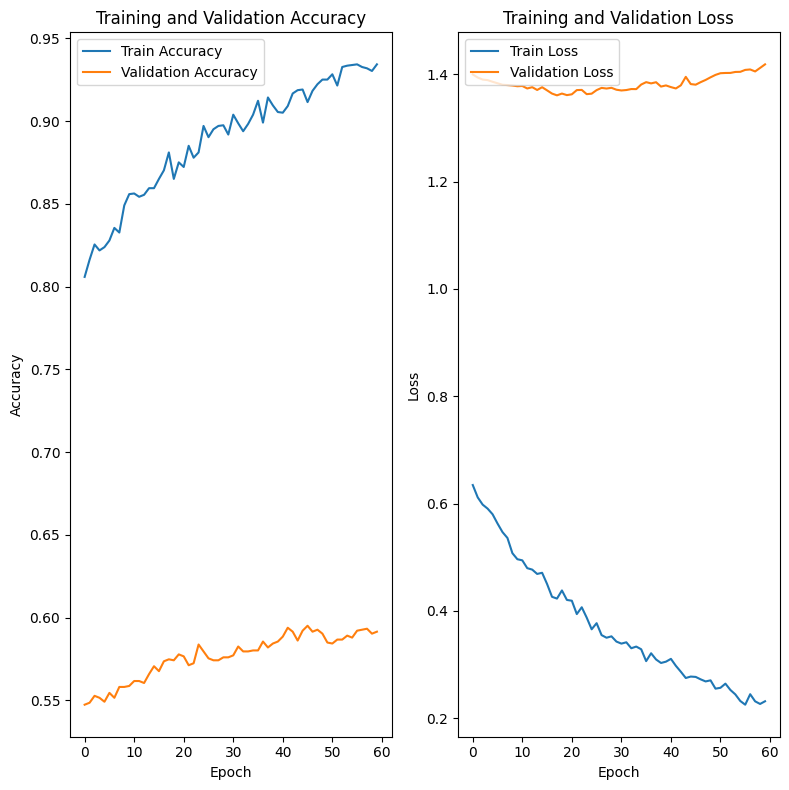

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8))

# แสดงกราฟค่า Accuracy
ax1.plot(history['accuracy'], label='Train Accuracy')
ax1.plot(history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='upper left')

# แสดงกราฟค่า Loss
ax2.plot(history['loss'], label='Train Loss')
ax2.plot(history['val_loss'], label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper left')

# แสดงกราฟทั้งหมดในรูปแบบแนวตั้ง
plt.tight_layout()
plt.show()

In [ ]:
num_epochs = len(history['accuracy'])

print(f'จำนวน Epochs ที่ใช้ในการฝึก: {num_epochs}')

จำนวน Epochs ที่ใช้ในการฝึก: 60
